# Thematische Analyse
Kongruenz nach Thema, Abstimmungstyp und Zeit.

In [28]:
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2
from visualisierungen import *

df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.info(50))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 151 columns):
 #    Column              Dtype  
---   ------              -----  
 0    anr                 float64
 1    datum               str    
 2    legisjahr           str    
 3    jahrzehnt           int64  
 4    rechtsform_name     str    
 5    titel_kurz_d        str    
 6    anzahl              int64  
 7    beteiligung         float64
 8    annahme             float64
 9    volkja-proz         float64
 10   berecht             float64
 11   stimmen             float64
 12   gultig              float64
 13   leer                float64
 14   hauptgruppe         str    
 15   untergruppe         str    
 16   kleinstgruppe       str    
 17   br-pos              float64
 18   br-pos_name         str    
 19   sr-pos              int64  
 20   nr-pos              int64  
 21   bv-pos              int64  
 

## 3. Kongruenz nach Thema (`hauptgruppe`)

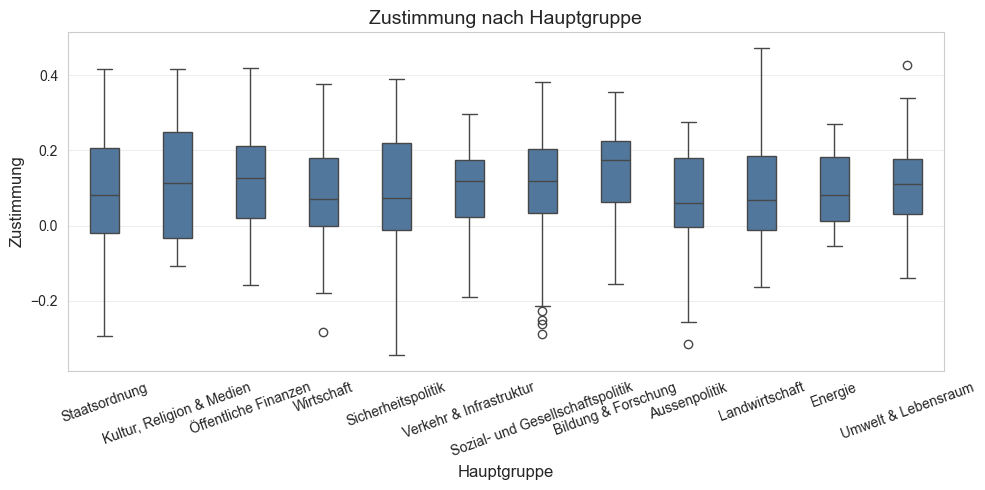

In [29]:
# Alle Zustimmungs-Spalten sammeln
boxplot(df, x="hauptgruppe", y="zustimmung_br-pos",
        titel="Zustimmung nach Hauptgruppe",
        xlabel="Hauptgruppe", ylabel="Zustimmung",
        figsize=(10, 5), rotation=20)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:6: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  """


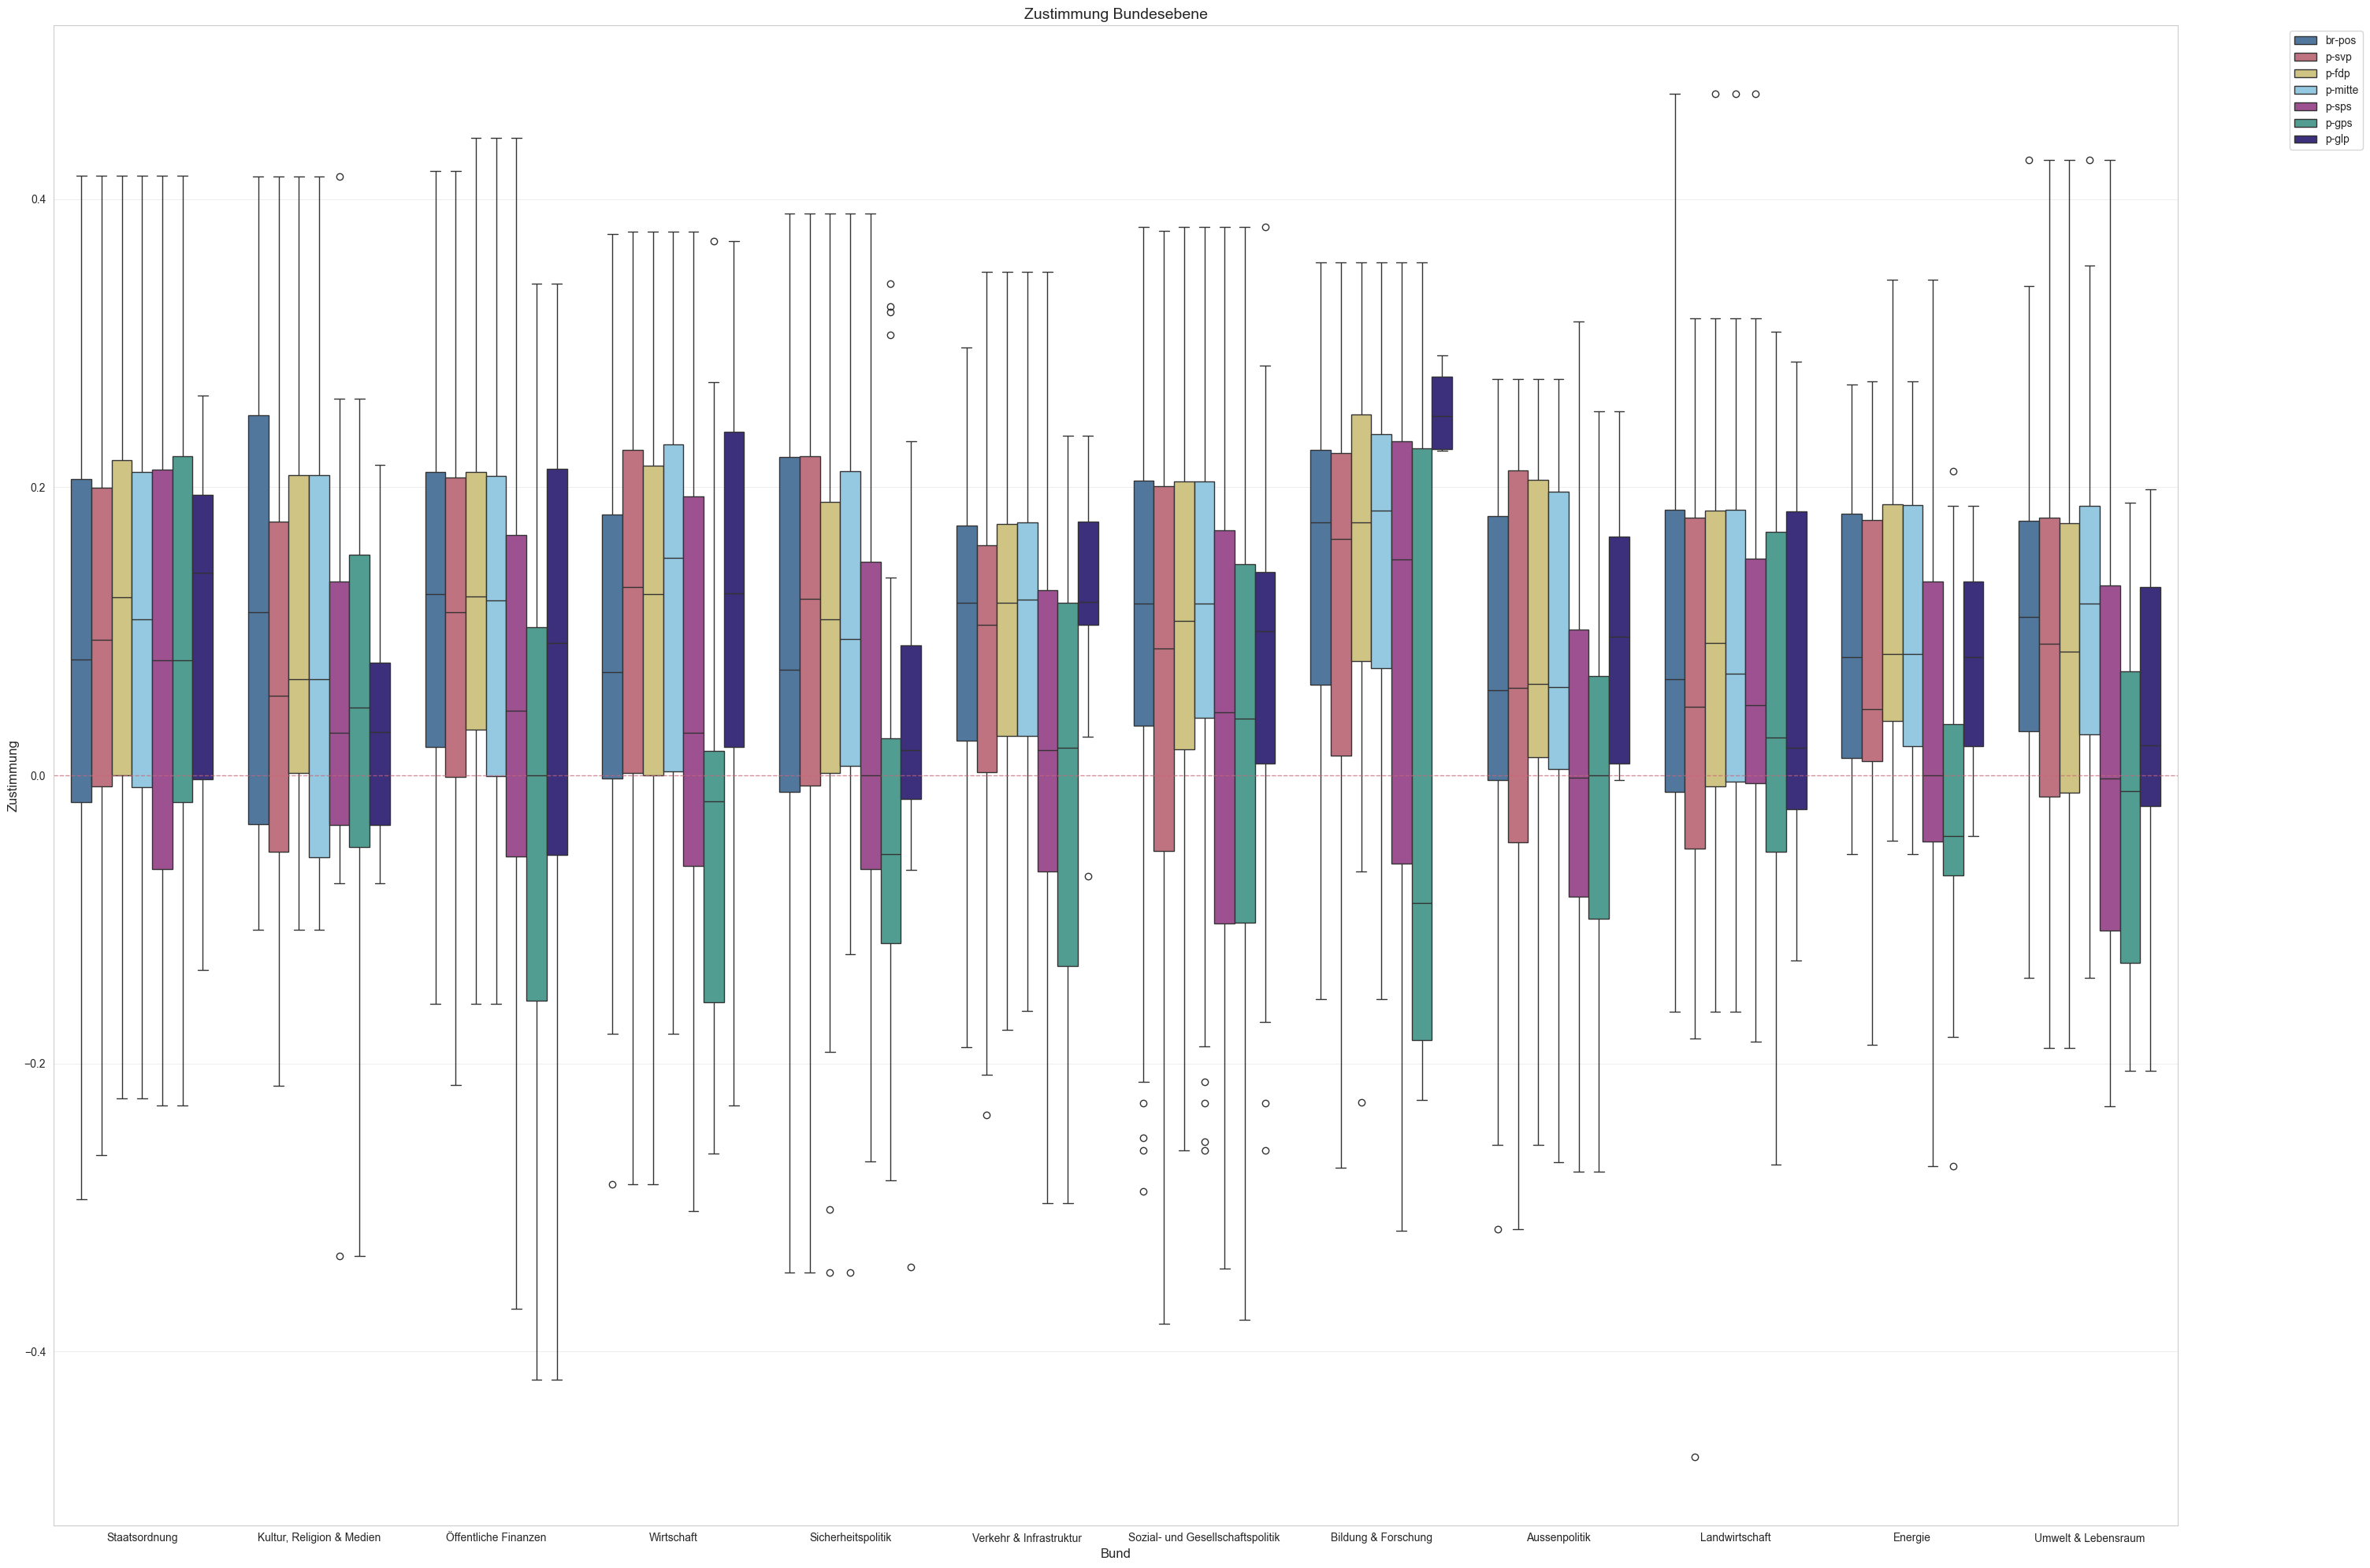

In [30]:
bund_cols = ["zustimmung_br-pos", "zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte",
            "zustimmung_p-sps", "zustimmung_p-gps", "zustimmung_p-glp"]

df_long = df[["hauptgruppe"] + bund_cols].melt(
    id_vars="hauptgruppe", var_name="bund", value_name="zustimmung")

df_long['bund'] = df_long['bund'].str.replace('zustimmung_', '')

boxplot(df_long, x="hauptgruppe", y="zustimmung", hue="bund", palette = PALETTE_KATEGORIAL_VIELE_WERTE,
        titel="Zustimmung Bundesebene",
        xlabel="Bund", ylabel="Zustimmung", hline = 0, width = 0.8,
        figsize=(30, 20))

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:6: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  """


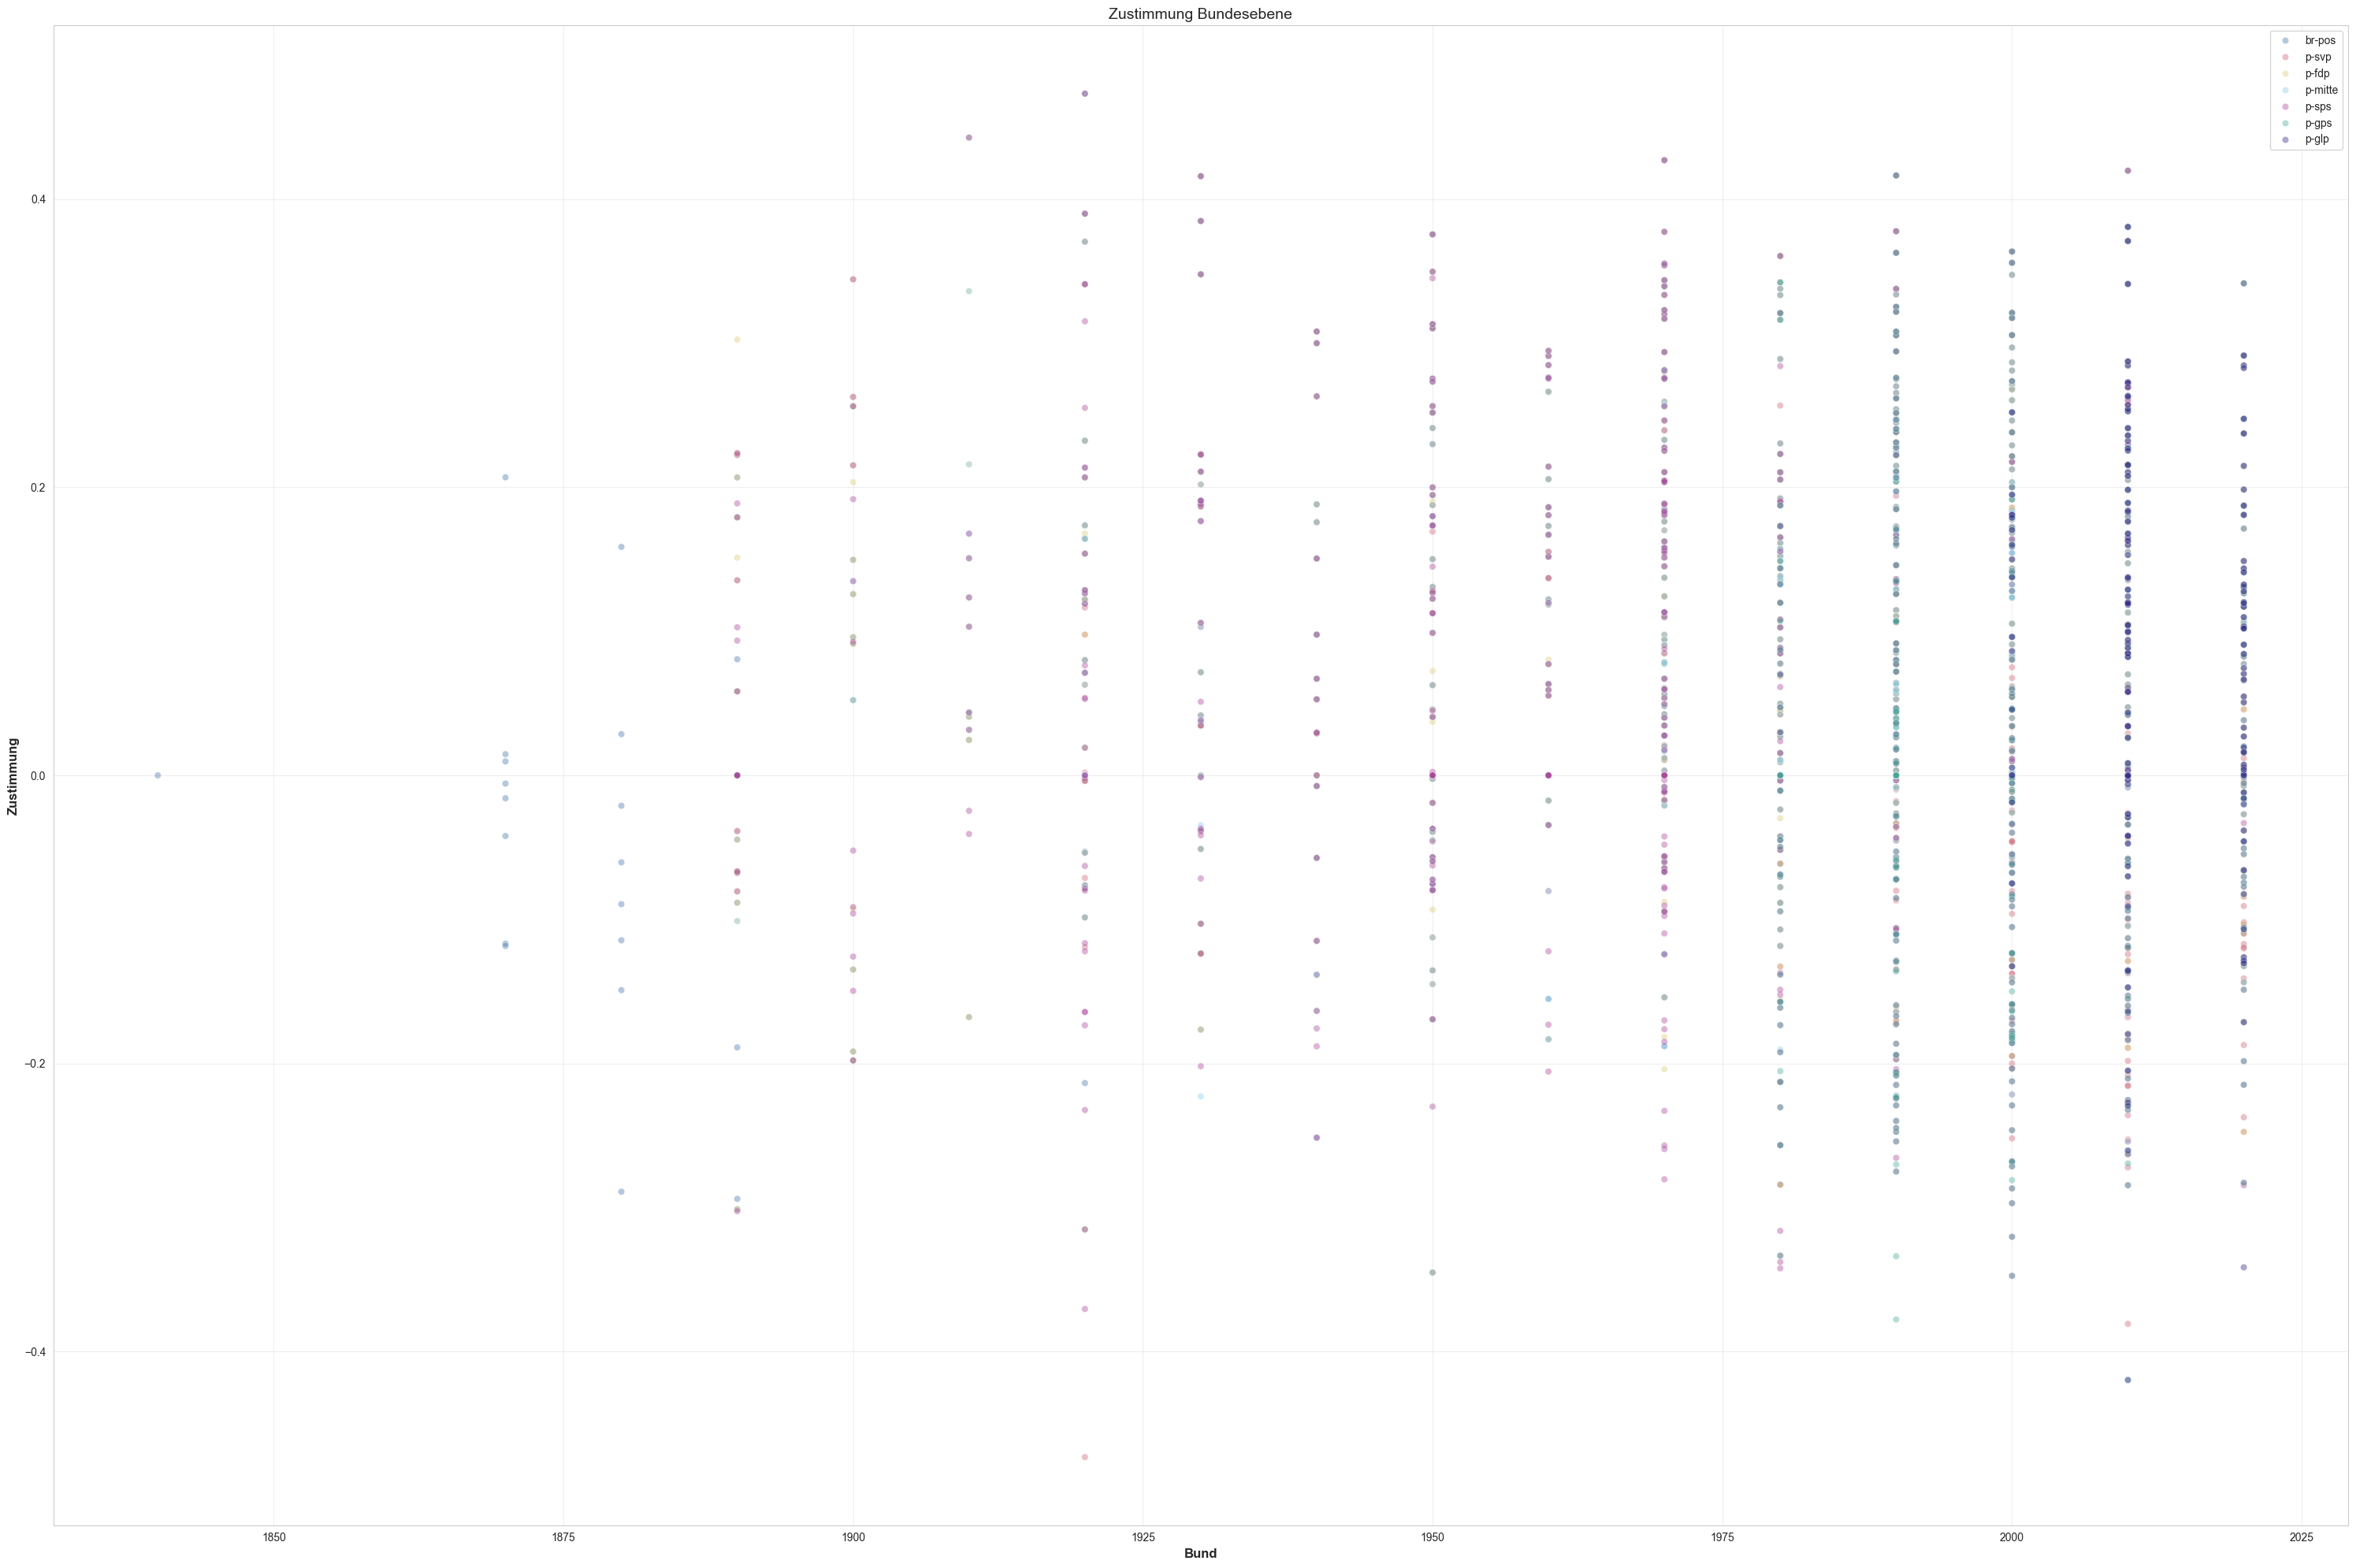

In [36]:
df_long = df[["jahrzehnt", "hauptgruppe"] + bund_cols].melt(
    id_vars=["jahrzehnt", "hauptgruppe"], var_name="bund", value_name="zustimmung")

df_long['bund'] = df_long['bund'].str.replace('zustimmung_', '')

scatterplot(df_long, x="jahrzehnt", y="zustimmung", hue="bund", palette = PALETTE_KATEGORIAL_VIELE_WERTE,
        titel="Zustimmung Bundesebene",
        xlabel="Bund", ylabel="Zustimmung",
        figsize=(30, 20))

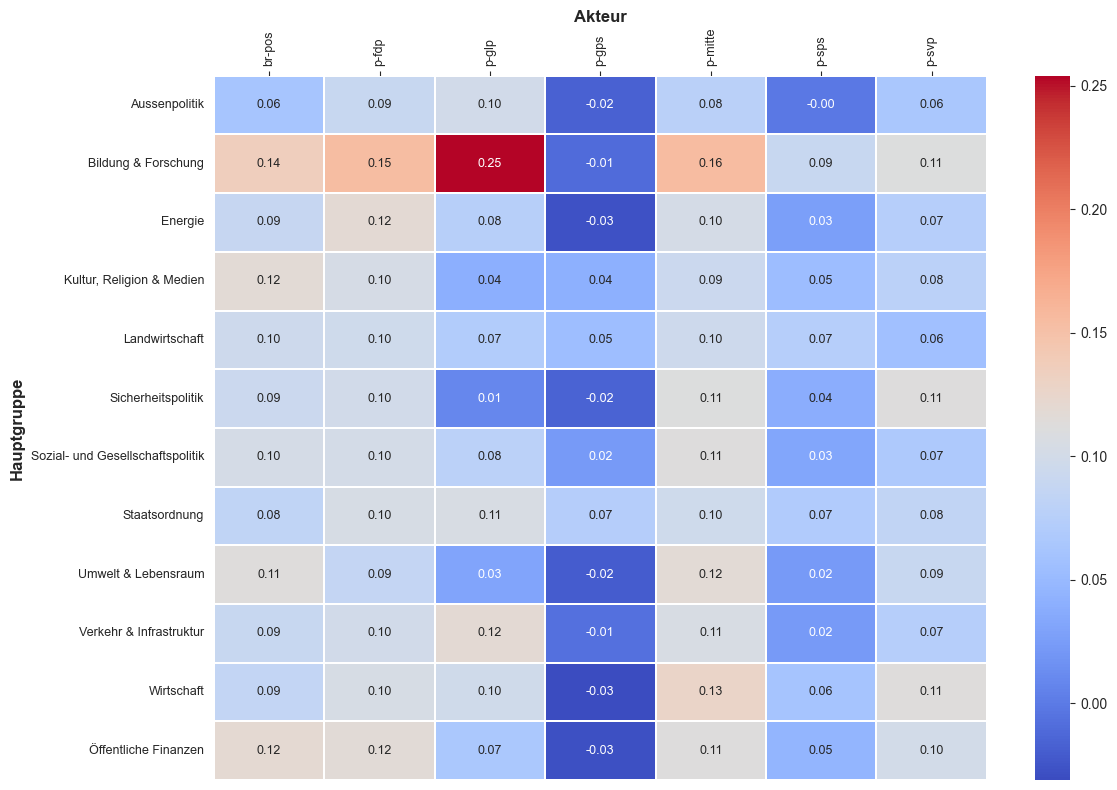

In [37]:
pivot = df_long.groupby(["hauptgruppe", "bund"])["zustimmung"].mean().unstack()

heatmap(pivot, xlabel="Akteur", ylabel="Hauptgruppe",
        cmap=CMAP_DIVERGIEREND, fmt=".2f", figsize=(12, 8), rotation=0)

/var/folders/pp/lkq7hgk93553k7jf082bnq1r0000gn/T/ipykernel_9106/24126294.py:9: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.lineplot(data=means, x="jahrzehnt", y="zustimmung", hue="bund",
/var/folders/pp/lkq7hgk93553k7jf082bnq1r0000gn/T/ipykernel_9106/24126294.py:9: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.lineplot(data=means, x="jahrzehnt", y="zustimmung", hue="bund",
/var/folders/pp/lkq7hgk93553k7jf082bnq1r0000gn/T/ipykernel_9106/24126294.py:9: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.lineplot(data=means, x="jahrzehnt", y="zustimmung", hue="bund",
/var/folders/pp/lkq7hgk93553k7jf082bnq1r0000gn/T/ipykernel_9106/24126294.py:9: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.lineplot(data=means, x="jahrzehnt", y="zustimmung", hue="bund",
/var/folders/pp/lkq7hgk9

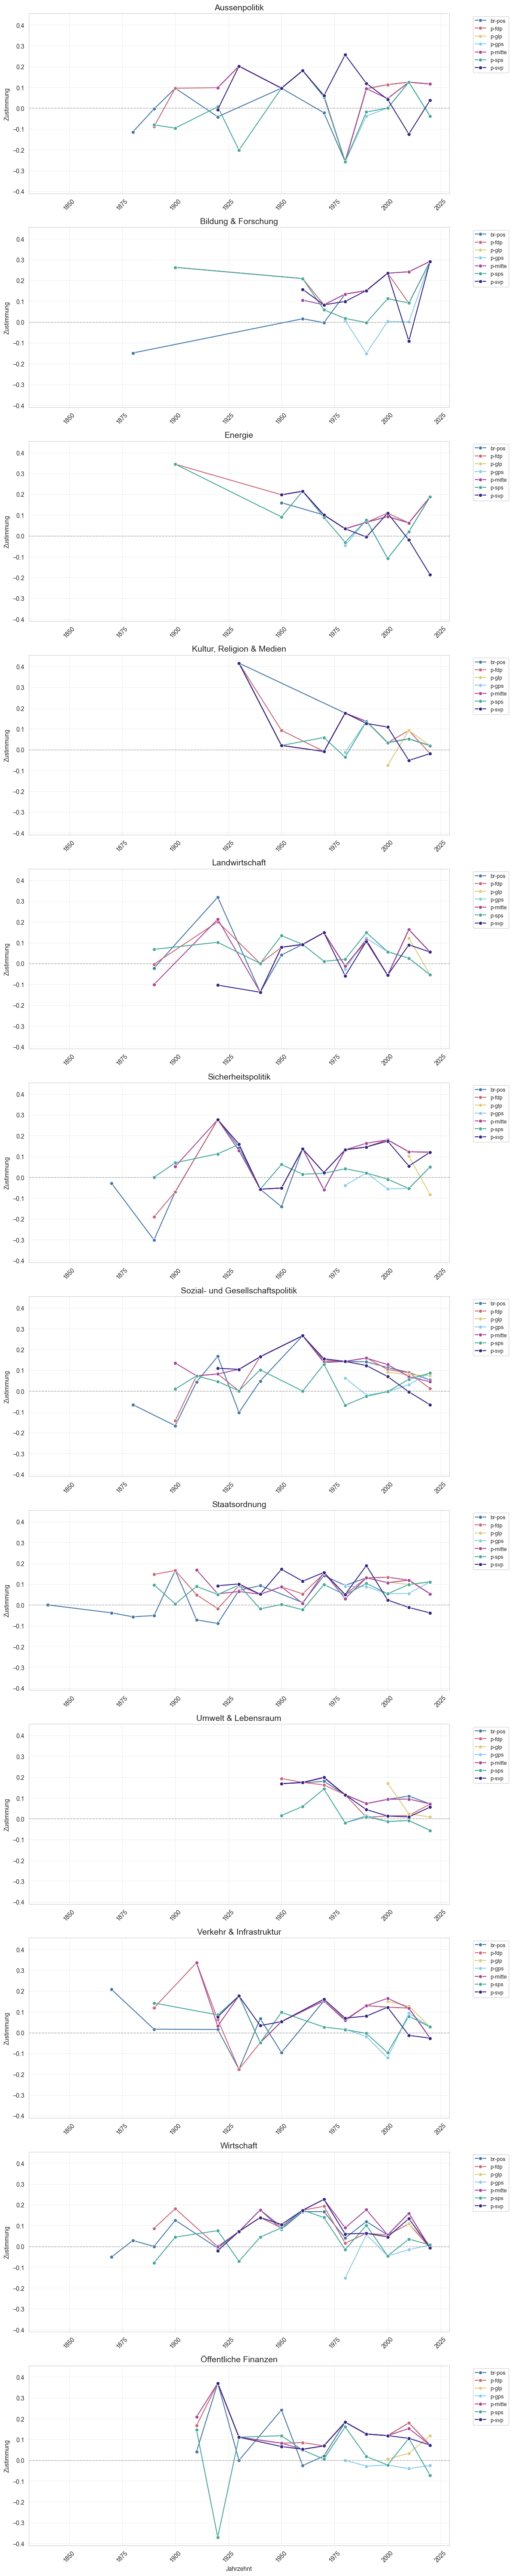

In [39]:
hauptgruppen = sorted(df_long['hauptgruppe'].dropna().unique())
n = len(hauptgruppen)

fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=True, sharey=True)

for ax, gruppe in zip(axes, hauptgruppen):
    subset = df_long[df_long['hauptgruppe'] == gruppe]
    means = subset.groupby(["jahrzehnt", "bund"])["zustimmung"].mean().reset_index()
    sns.lineplot(data=means, x="jahrzehnt", y="zustimmung", hue="bund",
                 marker="o", palette=PALETTE_KATEGORIAL_VIELE_WERTE, ax=ax)
    ax.axhline(0, color="#888888", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(gruppe, fontsize=14)
    ax.set_ylabel("Zustimmung")
    ax.tick_params(axis='x', labelbottom=True, rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

axes[-1].set_xlabel("Jahrzehnt")
plt.tight_layout()
plt.show()